In [4]:
import matplotlib.pyplot as plt
import numpy as np
import pandas as pd
import seaborn as sns
from scipy.stats import gaussian_kde
from sklearn.decomposition import PCA
from sklearn.manifold import MDS, TSNE
from sklearn.preprocessing import StandardScaler
from utils import *


In [5]:
plt.rcParams.update({
    'font.size': 7,
    'axes.titlesize': 7,
    'axes.labelsize': 7,
    'xtick.labelsize': 7,
    'ytick.labelsize': 7,
    'legend.fontsize': 7,
    'figure.titlesize': 7
})

cm_to_inch = 1 / 2.54
width = 4.5
figsize_cm = (width * cm_to_inch, width * cm_to_inch)  # (9cm, 9cm)
fig_size = figsize_cm

In [ ]:
'''
load data include design fastas, lables, and computational metric
PDN35: a isolate data that with the RMSD varaince > 10 while others lower than 3
'''
def reduce_matrix(matrix, seed = 42, labels = None, perplexity = None):
    
    # Reduce the matrix to 2 dimensions with MDS
    mds = MDS(n_components=2, random_state=seed, dissimilarity='precomputed')
    tsne = TSNE(n_components=2, random_state=seed, perplexity=perplexity)
    pca = PCA(n_components=2)
    
    scaler = StandardScaler()   # Shape remains (46, 46)
    
    coords = mds.fit_transform(matrix)   # Shape is (29, 2)
    return coords
    
def preprocess(csv_file, perplexity = 30):
    source_df = pd.read_csv(csv_file)
    
    with35 = True
    if not with35:df = source_df[~source_df['Name'].str.contains('PDN35', na=False)]
    else:df = source_df
        
    labels = df["Name"]
    fasta_list = list(df['Sequence'])
   
    matrix = 1 - get_identity_matrix(fasta_list)
    coords = reduce_matrix(matrix, seed = 742, labels = labels,perplexity = perplexity)
    return coords, source_df

d:\miniconda3\envs\plot\lib\site-packages\sklearn\manifold\_mds.py:677: FutureWarning: The default value of `n_init` will change from 4 to 1 in 1.9.
  warnings.warn(


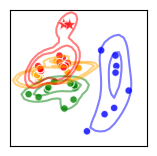

In [ ]:
# plot all data on a plot 
for i in range(1,2):
    coords, df = preprocess('../data/r0-3.csv', perplexity = i)
    
    zips = [
            (0, -1, 'all', '#B6B3D6'),
            # (0,0 + 1,'native', '#D5D3DE'),
            (1,  1  + 8, 'round0', '#D6B3D6'),
            (9,  9  + 10, 'round1', '#B6B3D6'),
            (19, 19 + 14,'round2', '#F6DFD6'),
            (33, 33 + 14, 'round3', '#E9687A')]
    

    np.random.seed(42)
    data = coords
    data0 = coords[zips[1][0]:zips[1][1]]
    data1 = coords[zips[2][0]:zips[2][1]]
    data2 = coords[zips[3][0]:zips[3][1]]
    data3 = coords[zips[4][0]:zips[4][1]]
    # ------------------------------
    
    # Use a shared coordinate range from the min/max x and y values
    all_x = coords[:,0]
    all_y = coords[:,1]
    x_min, x_max = all_x.min(), all_x.max()
    y_min, y_max = all_y.min(), all_y.max()
    
    # interpolate the values while the designs only 38
    grid_size = 30
    region = 0.2
    xi = np.linspace(x_min - region, x_max + region, grid_size)
    yi = np.linspace(y_min - region, y_max + region, grid_size)
    XI, YI = np.meshgrid(xi, yi)
    positions = np.vstack([XI.ravel(), YI.ravel()])
    
    # Define a plotting helper that computes KDE and returns grid density
    def get_kde_grid(data, positions):
        kde = gaussian_kde(data.T)          # data.T has shape (2, N)
        density = kde(positions).reshape(XI.shape)
        return density
    
    # Compute density for each dataset
    density0 = get_kde_grid(data0, positions)
    density1 = get_kde_grid(data1, positions)
    density2 = get_kde_grid(data2, positions)
    density3 = get_kde_grid(data3, positions)
    
    level0 = [1,2]
    level1 = 2
    level2 = [1,2]
    level3 = [1,2]
    # ------------------------------
    # Plot the figure
    colors = ['blue', 'green',  'Orange','red']
    fig = plt.figure(figsize=fig_size)
    levels = 3
    fill = False
    if fill:
        # fill lines
        cmaps = ['Blues', 'Greens','Oranges','Reds']
        plt.contourf(XI, YI, density0, levels=level0, alpha=0.3, cmap=cmaps[0])
        plt.contourf(XI, YI, density1, levels=level1, alpha=0.3, cmap=cmaps[1])
        plt.contourf(XI, YI, density2, levels=level2, alpha=0.3, cmap=cmaps[2])
        plt.contourf(XI, YI, density3, levels=level3, alpha=0.3, cmap=cmaps[3])
        
    # plot lines
    contour0 = plt.contour(XI, YI, density0, levels=level0, colors=colors[0], linewidths=1.5, alpha=0.5)
    contour1 = plt.contour(XI, YI, density1, levels=level1, colors=colors[1], linewidths=1.5, alpha=0.5)
    contour2 = plt.contour(XI, YI, density2, levels=level2, colors=colors[2], linewidths=1.5, alpha=0.5)
    contour3 = plt.contour(XI, YI, density3, levels=level3, colors=colors[3], linewidths=1.5, alpha=0.5)
    
    df['x'] = coords[:,0]
    df['y'] = coords[:,1]
    df['Wet-lab'] = df['Alkaline resistance'].str.contains('Yes', na=False)
    # scatter the designs
    
    markers = {True: "*", False: "."}
    sns.scatterplot(df[1:], x = 'x', y = 'y', palette = colors, hue = 'Round', style = 'Wet-lab', markers = markers, s=120, alpha = 0.8)
    
    
    plt.xticks([])
    plt.yticks([])
    plt.gca().get_legend().remove()
    plt.xlabel(None)      # Remove the existing label
    plt.ylabel(None)
 
    plt.savefig('equal_line.svg', dpi = 300)
    plt.show()